In [17]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [2]:
DATA_PATH = '../data/02_failure_classification_features.csv'
df = pd.read_csv(DATA_PATH)

print(df.head())
print(df.shape)
print(df['risk_level'].value_counts())

  vehicle_id snapshot_date     make   model  year  mileage_km  \
0    VH-0001    2024-01-01  Hyundai  Tucson  2019       57887   
1    VH-0001    2024-01-01  Hyundai  Tucson  2019       57887   
2    VH-0001    2024-01-01  Hyundai  Tucson  2019       57887   
3    VH-0001    2024-01-01  Hyundai  Tucson  2019       57887   
4    VH-0001    2024-01-01  Hyundai  Tucson  2019       57887   

   vehicle_age_years       component  km_since_oil_change  \
0                  7         battery                 6724   
1                  7          brakes                 6724   
2                  7  cooling_system                 6724   
3                  7    transmission                 6724   
4                  7          engine                 6724   

   km_since_brake_service  ...  dtc_count_30d  dtc_count_90d  rpm_speed_ratio  \
0                   10450  ...              1              0            69.86   
1                   10450  ...              1              0            69.86   

In [3]:
print(df.columns)

Index(['vehicle_id', 'snapshot_date', 'make', 'model', 'year', 'mileage_km',
       'vehicle_age_years', 'component', 'km_since_oil_change',
       'km_since_brake_service', 'km_since_battery_change',
       'km_since_coolant_flush', 'avg_rpm_30d', 'std_rpm_30d',
       'avg_coolant_temp_30d', 'max_coolant_temp_30d', 'avg_voltage_30d',
       'min_voltage_30d', 'avg_speed_30d', 'avg_throttle_30d',
       'fuel_trim_mean_30d', 'fuel_trim_std_30d', 'dtc_count_7d',
       'dtc_count_30d', 'dtc_count_90d', 'rpm_speed_ratio',
       'coolant_delta_30d', 'voltage_drop_30d', 'driving_aggression_score',
       'idle_time_pct', 'highway_pct', 'total_engine_hours', 'risk_level'],
      dtype='object')


In [4]:
for col in df.columns:
    if df[col].dtype in ['int64', 'float64']:
        df[col] = df[col].fillna(df[col].median())
    else:
        df[col] = df[col].fillna(df[col].mode()[0])

In [5]:
target_column = 'risk_level'
columns_to_drop = ['vehicle_id', 'snapshot_date', target_column]

X = df.drop(columns=columns_to_drop)
y = df[target_column]

In [6]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

for i, cls in enumerate(label_encoder.classes_):
    print(f'{cls} -> {i}')

high_risk -> 0
low_risk -> 1
medium_risk -> 2
no_risk -> 3


In [7]:
X = pd.get_dummies(X, drop_first=True)
feature_names = X.columns.tolist()

print('Number of features:', len(feature_names))

Number of features: 64


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

In [9]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=3000),
    'Random Forest': RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'SVM': SVC(probability=True),
    'KNN': KNeighborsClassifier(n_neighbors=5)
}

In [11]:
results = []
best_model = None
best_model_name = None
best_f1 = 0

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    })

    if f1 > best_f1:
        best_f1 = f1
        best_model = model
        best_model_name = name

print('Best model:', best_model_name)
print('Best F1:', best_f1)

Best model: Gradient Boosting
Best F1: 0.6795296287754561


In [12]:
results_df = pd.DataFrame(results).sort_values(by='F1-Score', ascending=False)
print(results_df)

                 Model  Accuracy  Precision    Recall  F1-Score
2    Gradient Boosting  0.699602   0.678318  0.699602  0.679530
1        Random Forest  0.567331   0.545560  0.567331  0.552594
3                  SVM  0.585657   0.547441  0.585657  0.543592
0  Logistic Regression  0.556175   0.521842  0.556175  0.520188
4                  KNN  0.396813   0.376403  0.396813  0.384515


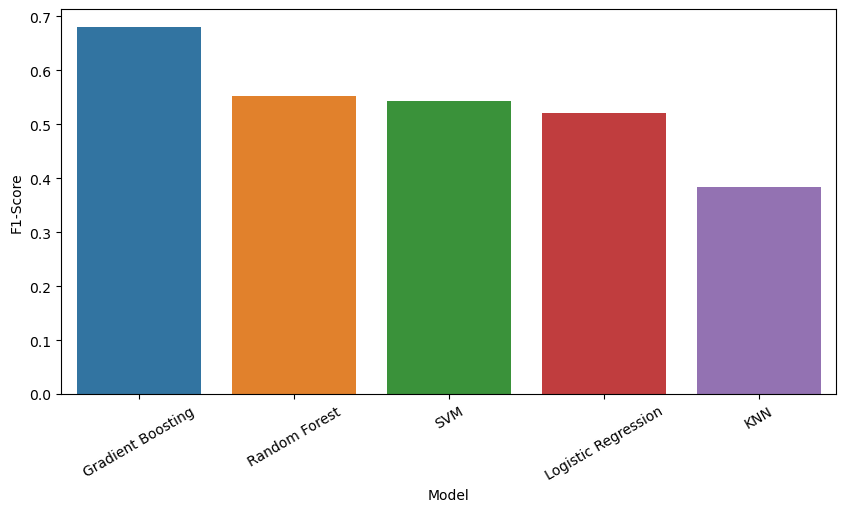

In [13]:
plt.figure(figsize=(10, 5))
sns.barplot(data=results_df, x='Model', y='F1-Score')
plt.xticks(rotation=30)
plt.show()

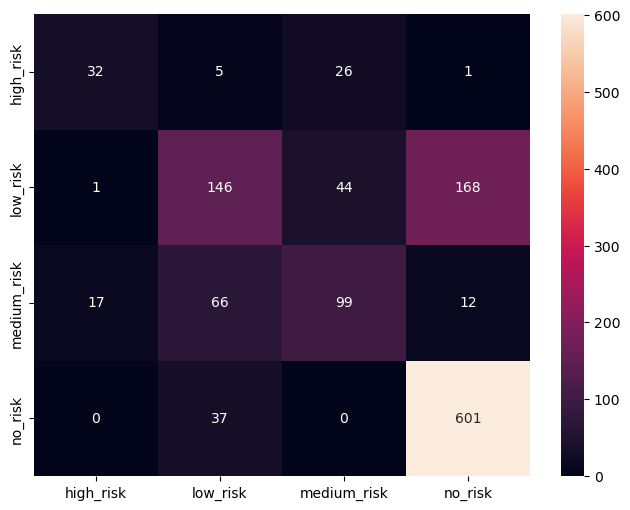

In [14]:
y_pred_best = best_model.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.show()

In [15]:
if hasattr(best_model, 'feature_importances_'):
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': best_model.feature_importances_
    }).sort_values(by='Importance', ascending=False)

    print(importance_df.head(20))

                     Feature  Importance
59  component_cooling_system    0.097973
10      max_coolant_temp_30d    0.091627
58          component_brakes    0.085119
63    component_transmission    0.069024
21         coolant_delta_30d    0.067590
62     component_fuel_system    0.060527
61          component_engine    0.059032
22          voltage_drop_30d    0.055708
15        fuel_trim_mean_30d    0.055017
60      component_electrical    0.051128
20           rpm_speed_ratio    0.032534
1                 mileage_km    0.030894
4     km_since_brake_service    0.029029
6     km_since_coolant_flush    0.028747
18             dtc_count_30d    0.027232
16         fuel_trim_std_30d    0.022603
2          vehicle_age_years    0.016531
8                std_rpm_30d    0.016439
23  driving_aggression_score    0.014698
5    km_since_battery_change    0.013928


In [16]:
os.makedirs('../models', exist_ok=True)

joblib.dump(best_model, '../models/best_failure_model.joblib')
joblib.dump(scaler, '../models/scaler.joblib')
joblib.dump(label_encoder, '../models/label_encoder.joblib')
joblib.dump(feature_names, '../models/feature_names.joblib')
results_df.to_csv('../models/model_comparison.csv', index=False)

print('Artifacts saved successfully.')

Artifacts saved successfully.
